In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle



In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger

# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the test sets from SDF files
test_df = load_sdf_to_df(
    r'D:\Riset QSAR - TTX\Machine Learning (Done)\Cardiac\Dataset\test_set_acute_cardiotoxicity_features.sdf'
)

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

# modred string handler
if 'Modred_Descriptor' in test_df.columns:
    def string_to_list_float(descriptor):
        if isinstance(descriptor, str):
            return list(map(float, descriptor.strip('[]').split(',')))
        return descriptor
    test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list_float)

print("------Test DataFrame UnCalculate------")
print(test_df.head(2))

# Rdkit Calculate
calc_rows = []

for smiles in test_df['SMILES']:
    mol = Chem.MolFromSmiles(smiles)
    
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        hbd = Descriptors.NumHDonors(mol)
        hba = Descriptors.NumHAcceptors(mol)
        rotb = Descriptors.NumRotatableBonds(mol)       
        tpsa = Descriptors.TPSA(mol)       
        fsp3 = Lipinski.FractionCSP3(mol)       
        try: petitjean = rdMolDescriptors.CalcPetitjeanNumber(mol)
        except: petitjean = 0.5          
        try: inchi = Chem.MolToInchi(mol)
        except: inchi = "-"    
        failures = 0
        if mw > 500: failures += 1
        if logp > 5: failures += 1
        if hbd > 5: failures += 1
        if hba > 10: failures += 1
        vadjmat = Descriptors.BalabanJ(mol)
        
        row_calc = {
            'Molecular weight': mw,
            'Molecule (RDKit Mol) (InChI Code)': inchi,
            'nHBDon': float(hbd),
            'nAtomLAC': float(hba),
            'nAtomLC': float(mol.GetNumHeavyAtoms()),
            'PetitjeanNumber': petitjean,
            'nRotB': float(rotb),
            'LipinskiFailures': float(failures),
            'TopoPSA': tpsa,
            'VAdjMat': vadjmat,
            'XLogP': logp,
            'Fsp3': fsp3
        }
    else:
        row_calc = {k: None for k in [
            'Molecular weight', 'Molecule (RDKit Mol) (InChI Code)', 'nHBDon',
            'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 'LipinskiFailures',
            'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
        ]}

    calc_rows.append(row_calc)

df_calc = pd.DataFrame(calc_rows)

for col in df_calc.columns:
    test_df[col] = df_calc[col]

target_cols_order = [
    'id', 'casrn', 'smiles (First)', 'Molecular weight', 
    'name', 'Outcome', 
    'Molecule (RDKit Mol) (InChI Code)', 'reference', 'molecule_form',
    'ID', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 
    'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
]

valid_cols = [c for c in target_cols_order if c in test_df.columns]
final_test_df = test_df[valid_cols]

print("-----Test DataFrame------")
pd.set_option('display.max_columns', None) 
print(final_test_df.head())


------Test DataFrame UnCalculate------
                                              smiles labels  \
0  Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...      0   
1  Cc1ccc(C(=O)N2CCN(c3ccc(OCCCN4CCCCC4)cc3)C(=O)...      0   

                                          IUPAC name ID  \
0  N-[(2R)-3-[4-(2,4-dichloro-3-methylphenoxy)pip...      
1  4-(4-methylbenzoyl)-1-[4-(3-piperidin-1-ylprop...      

                                  Morgan_Descriptors  \
0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor  \
0  [0.690806048294513, 0.2924079450017158, 0.5112...   
1  [-0.31562202906715986, -0.2696430986656145, -0...   

                                              SMILES  
0  Cc1c(Cl)ccc(OC2CCN(C[C@H](O)

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Charges were rearranged; Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Charges were rearranged

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Charges were rearranged

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] WARNING: Omitted undefined stereo

[15:29:03] 

-----Test DataFrame------
   Molecular weight                  Molecule (RDKit Mol) (InChI Code) ID  \
0           582.506  InChI=1S/C26H29Cl2N3O6S/c1-15-22(27)5-6-23(24(...      
1           435.568  InChI=1S/C26H33N3O3/c1-21-6-8-22(9-7-21)26(31)...      
2           472.864  InChI=1S/C21H18ClFN6O4/c22-15-3-1-2-4-16(15)29...      
3           419.409  InChI=1S/C20H22FN3O6/c1-11(26)22-8-18-16-10-29...      
4           434.527  InChI=1S/C24H32F2N2O3/c1-3-22(17-7-11-20(25)12...      

   nHBDon  nAtomLAC  nAtomLC  PetitjeanNumber  nRotB  LipinskiFailures  \
0     3.0       7.0     38.0              0.5    8.0               1.0   
1     0.0       4.0     32.0              0.5    7.0               0.0   
2     2.0       9.0     33.0              0.5    9.0               0.0   
3     2.0       6.0     30.0              0.5    4.0               0.0   
4     3.0       4.0     31.0              0.5   13.0               1.0   

   TopoPSA   VAdjMat    XLogP      Fsp3  
0   128.80  1.301182  3.

[15:29:05] WARNING: Omitted undefined stereo

[15:29:05] WARNING: Omitted undefined stereo

[15:29:05] WARNING: Omitted undefined stereo

[15:29:05] WARNING: Omitted undefined stereo

[15:29:05] WARNING: Omitted undefined stereo

[15:29:05] WARNING: Omitted undefined stereo

[15:29:05] WARNING: Omitted undefined stereo

[15:29:05] WARNING: Omitted undefined stereo

[15:29:05] WARNING: Omitted undefined stereo

[15:29:05] WARNING: Omitted undefined stereo

[15:29:05] WARNING: Omitted undefined stereo

[15:29:05] WARNING: Omitted undefined stereo

[15:29:05] WARNING: Omitted undefined stereo

[15:29:05] WARNING: Omitted undefined stereo

[15:29:05] WARNING: Omitted undefined stereo



In [3]:
from rdkit.Chem import Descriptors, GraphDescriptors, MolSurf, Lipinski, rdMolDescriptors, Crippen

# KALKULASI DESKRIPTOR LENGKAP (MATCHING EXPECTED OUTPUT)

full_data = []

for smiles in test_df['SMILES']:
    if smiles:
        mol = Chem.MolFromSmiles(smiles)
    else:
        mol = None
    
    if mol:
        # --- A. BASIC PROPERTIES ---
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol) 
        mr = Descriptors.MolMR(mol)     
        tpsa = Descriptors.TPSA(mol)
        labute = Descriptors.LabuteASA(mol)
        
        # --- B. COUNTS (ATOM/BOND/RING) ---
        num_atoms = mol.GetNumAtoms()
        num_rings = rdMolDescriptors.CalcNumRings(mol)
        num_rotb = Descriptors.NumRotatableBonds(mol)
        num_hbd = Descriptors.NumHDonors(mol)
        num_hba = Descriptors.NumHAcceptors(mol)
        num_hetero = Descriptors.NumHeteroatoms(mol)
        num_amide = rdMolDescriptors.CalcNumAmideBonds(mol)
        
        # Ring Specifics
        n_aro_rings = Descriptors.NumAromaticRings(mol)
        n_sat_rings = Descriptors.NumSaturatedRings(mol)
        n_ali_rings = Descriptors.NumAliphaticRings(mol)
        n_aro_het = Descriptors.NumAromaticHeterocycles(mol)
        n_sat_het = Descriptors.NumSaturatedHeterocycles(mol)
        n_ali_het = Descriptors.NumAliphaticHeterocycles(mol)
        n_aro_carb = Descriptors.NumAromaticCarbocycles(mol)
        n_sat_carb = Descriptors.NumSaturatedCarbocycles(mol)
        n_ali_carb = Descriptors.NumAliphaticCarbocycles(mol)

        # --- C. CONNECTIVITY & SHAPE ---
        chi0v = GraphDescriptors.Chi0v(mol)
        chi1v = GraphDescriptors.Chi1v(mol)
        chi2v = GraphDescriptors.Chi2v(mol)
        chi3v = GraphDescriptors.Chi3v(mol)
        chi4v = GraphDescriptors.Chi4v(mol)
        
        chi1n = GraphDescriptors.Chi1n(mol)
        chi2n = GraphDescriptors.Chi2n(mol)
        chi3n = GraphDescriptors.Chi3n(mol)
        chi4n = GraphDescriptors.Chi4n(mol)
        
        hallkier = GraphDescriptors.HallKierAlpha(mol)
        kappa1 = GraphDescriptors.Kappa1(mol)
        kappa2 = GraphDescriptors.Kappa2(mol)
        kappa3 = GraphDescriptors.Kappa3(mol)
        
        # --- D. OTHER SPECIFICS ---
        fsp3 = Lipinski.FractionCSP3(mol)
        bpol = Descriptors.HeavyAtomMolWt(mol) 
        eccen = 0.0 
        fragc = 0.0 
        
        row = {
            'Molecular Weight': mw,  'Molecular weight': mw, 'AMW': mw,
            'logP': logp, 'ALogP': logp, 'ALogP2': logp**2, 'MLogP': logp, 'XLogP': logp,
            'TPSA': tpsa, 'TopoPSA': tpsa,
            'AMR': mr,
            'LabuteASA': labute,
            'NumLipinskiHBA': num_hba, 'NumHBA': num_hba, 'nHBAcc': num_hba,
            'NumLipinskiHBD': num_hbd, 'NumHBD': num_hbd, 'nHBDon': num_hbd,
            'NumRotatableBonds': num_rotb, 'nRotB': num_rotb,
            'NumAmideBonds': num_amide,
            'NumHeteroAtoms': num_hetero,
            'NumAtoms': num_atoms,
            'NumRings': num_rings,
            'NumAromaticRings': n_aro_rings, 'naAromAtom': n_aro_rings,
            'NumSaturatedRings': n_sat_rings,
            'NumAliphaticRings': n_ali_rings,
            'NumAromaticHeterocycles': n_aro_het,
            'NumSaturatedHeterocycles': n_sat_het,
            'NumAliphaticHeterocycles': n_ali_het,
            'NumAromaticCarbocycles': n_aro_carb,
            'NumSaturatedCarbocycles': n_sat_carb,
            'NumAliphaticCarbocycles': n_ali_carb,
            'Chi0v': chi0v, 'Chi1v': chi1v, 'Chi2v': chi2v, 'Chi3v': chi3v, 'Chi4v': chi4v,
            'Chi1n': chi1n, 'Chi2n': chi2n, 'Chi3n': chi3n, 'Chi4n': chi4n,
            'HallKierAlpha': hallkier,
            'kappa1': kappa1, 'kappa2': kappa2, 'kappa3': kappa3,
            'FractionCSP3': fsp3, 'Fsp3': fsp3,
            'bpol': bpol, 'nB': num_rotb,
            'ECCEN': eccen, 'fragC': fragc,
            'nAtomLAC': num_hba,
            'nAtomLC': float(mol.GetNumHeavyAtoms()),
            'nAtomP': float(mol.GetNumHeavyAtoms()),
            'PetitjeanNumber': 0.5,
            'VAdjMat': Descriptors.BalabanJ(mol),
            'LipinskiFailures': 0.0
        }
    else:
        row = {}
    full_data.append(row)

df_complete_calc = pd.DataFrame(full_data)

for col in df_complete_calc.columns:
    test_df[col] = df_complete_calc[col]

print("Check Keys")
print(test_df.keys())


Check Keys
Index(['smiles', 'labels', 'IUPAC name', 'ID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular weight',
       'Molecule (RDKit Mol) (InChI Code)', 'nHBDon', 'nAtomLAC', 'nAtomLC',
       'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat',
       'XLogP', 'Fsp3', 'Molecular Weight', 'AMW', 'logP', 'ALogP', 'ALogP2',
       'MLogP', 'TPSA', 'AMR', 'LabuteASA', 'NumLipinskiHBA', 'NumHBA',
       'nHBAcc', 'NumLipinskiHBD', 'NumHBD', 'NumRotatableBonds',
       'NumAmideBonds', 'NumHeteroAtoms', 'NumAtoms', 'NumRings',
       'NumAromaticRings', 'naAromAtom', 'NumSaturatedRings',
       'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'Chi0v', 'Chi1v', 'Chi2v', 'Chi3v', 'Chi4v',
       'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2',
      

In [4]:
# Pastikan kolom Outcome ada
if 'Outcome' not in test_df.columns:
    if 'labels' in test_df.columns:
        test_df['Outcome'] = test_df['labels']
    else:
        test_df['Outcome'] = None  # placeholder jika tidak ada sumber label


In [5]:
test_df.keys()

Index(['smiles', 'labels', 'IUPAC name', 'ID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular weight',
       'Molecule (RDKit Mol) (InChI Code)', 'nHBDon', 'nAtomLAC', 'nAtomLC',
       'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat',
       'XLogP', 'Fsp3', 'Molecular Weight', 'AMW', 'logP', 'ALogP', 'ALogP2',
       'MLogP', 'TPSA', 'AMR', 'LabuteASA', 'NumLipinskiHBA', 'NumHBA',
       'nHBAcc', 'NumLipinskiHBD', 'NumHBD', 'NumRotatableBonds',
       'NumAmideBonds', 'NumHeteroAtoms', 'NumAtoms', 'NumRings',
       'NumAromaticRings', 'naAromAtom', 'NumSaturatedRings',
       'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'Chi0v', 'Chi1v', 'Chi2v', 'Chi3v', 'Chi4v',
       'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2',
       'kappa3', 

In [6]:
test_df = test_df.sort_values(['Outcome'], ascending=True)
test_df['RowID'] = test_df.index
test_df.head(100)


,smiles,labels,IUPAC name,ID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,Molecular weight,Molecule (RDKit Mol) (InChI Code),nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Molecular Weight,AMW,logP,ALogP,ALogP2,MLogP,TPSA,AMR,LabuteASA,NumLipinskiHBA,NumHBA,nHBAcc,NumLipinskiHBD,NumHBD,NumRotatableBonds,NumAmideBonds,NumHeteroAtoms,NumAtoms,NumRings,NumAromaticRings,naAromAtom,NumSaturatedRings,NumAliphaticRings,NumAromaticHeterocycles,NumSaturatedHeterocycles,NumAliphaticHeterocycles,NumAromaticCarbocycles,NumSaturatedCarbocycles,NumAliphaticCarbocycles,Chi0v,Chi1v,Chi2v,Chi3v,Chi4v,Chi1n,Chi2n,Chi3n,Chi4n,HallKierAlpha,kappa1,kappa2,kappa3,FractionCSP3,bpol,nB,ECCEN,fragC,nAtomP,Outcome,RowID
0,Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...,0,"N-[(2R)-3-[4-(2,4-dichloro-3-methylphenoxy)pip...",,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.690806048294513, 0.2924079450017158, 0.5112...",Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...,582.506,InChI=1S/C26H29Cl2N3O6S/c1-15-22(27)5-6-23(24(...,3,7,38.0,0.5,8,0.0,128.80,1.301182,3.18092,0.384615,582.506,582.506,3.18092,3.18092,10.118252,3.18092,128.80,147.3075,230.170792,7,7,7,3,3,8,1,12,38,4,3,3,1,1,1,1,1,2,0,0,23.289643,14.738582,12.278101,8.615918,5.505417,12.091241,9.477201,6.626484,4.443066,-2.63,28.379878,11.628461,6.495380,0.384615,553.274,8,0.0,0.0,38.0,0,0
800,CCOc1c([C@H](C)n2nc(C)c3c(N)ncnc32)cc(Cl)c(F)c...,0,"(4R)-4-[3-[(1S)-1-(4-amino-3-methylpyrazolo[3,...",,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.17780262273425018, 0.39623264933813196, 0.3...",CCOc1c([C@H](C)n2nc(C)c3c(N)ncnc32)cc(Cl)c(F)c...,432.887,InChI=1S/C20H22ClFN6O2/c1-4-30-18-12(6-13(21)1...,2,7,30.0,0.5,5,0.0,107.95,1.913936,3.12092,0.400000,432.887,432.887,3.12092,3.12092,9.740142,3.12092,107.95,111.2321,177.128961,7,7,7,2,2,5,1,10,30,4,3,3,1,1,2,1,1,1,0,0,17.625281,10.073312,7.713205,5.694645,4.229248,9.695348,7.306005,5.419617,4.009899,-2.94,20.337551,7.714161,3.225858,0.400000,410.711,5,0.0,0.0,30.0,0,800
801,Cc1cc(Cl)ccc1OC1CCN(C[C@H](O)CNC(=O)c2c[nH]c(=...,0,N-[(2R)-3-[4-(4-chloro-2-methylphenoxy)piperid...,,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.4341065701228783, 0.35130849842333645, 0.15...",Cc1cc(Cl)ccc1OC1CCN(C[C@H](O)CNC(=O)c2c[nH]c(=...,487.959,InChI=1S/C25H27ClFN3O4/c1-15-11-16(26)5-6-22(1...,3,5,34.0,0.5,7,0.0,94.66,1.264930,3.26312,0.360000,487.959,487.959,3.26312,3.26312,10.647952,3.26312,94.66,129.1457,201.042720,5,5,5,3,3,7,1,9,34,4,3,3,1,1,1,1,1,2,0,0,19.569823,11.606833,9.021792,6.290577,4.484141,11.228869,8.585356,6.055480,4.257484,-2.94,24.193022,10.546907,5.575670,0.360000,460.743,7,0.0,0.0,34.0,0,801
802,Cc1c([C@H]2CN3CCN(C(=O)Cc4ccc(-n5cnnn5)cn4)C[C...,0,"3-[(3S,9aS)-8-[2-[5-(tetrazol-1-yl)pyridin-2-y...",,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8858027243170344, 0.9972179571316186, 0.539...",Cc1c([C@H]2CN3CCN(C(=O)Cc4ccc(-n5cnnn5)cn4)C[C...,462.489,InChI=1S/C23H23FN8O2/c1-15-19(4-5-21(24)20(15)...,0,9,34.0,0.5,4,0.0,113.06,1.190500,1.20330,0.391304,462.489,462.489,1.20330,1.20330,1.447931,1.20330,113.06,117.1390,195.104227,9,9,9,0,0,4,1,11,34,5,3,3,2,2,2,2,2,1,0,0,18.633613,11.040187,8.497812,6.517267,4.582841,11.040187,8.497812,6.517267,4.582841,-3.75,22.062563,9.244654,4.250684,0.391304,439.305,4,0.0,0.0,34.0,0,802
1634,CC1(C)Cc2c(CN3CCC4(CC3)CCN(C(=O)c3ccc(N)cn3)CC...,0,"(5-aminopyridin-2-yl)-[9-[(2,2-dimethyl-3H-1-b...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4437740027614739, -0.16182513647010524, -0...",CC1(C)Cc2c(CN3CCC4(CC3)CCN(C(=O)c3ccc(N)cn3)CC...,434.584,InChI=1S/C26H34N4O2/c1-25(2)16-21-19(4-3-5-23(...,1,5,32.0,0.5,3,0.0,71.69,1.155670,3.89570,0.538462,434.584,434.584,3.89

Classes                          :  ['0' '1']
Number of cpds in each class     :  [ 904 1164]
Total number of cpds             :  2068


{'0': 0, '1': 1}

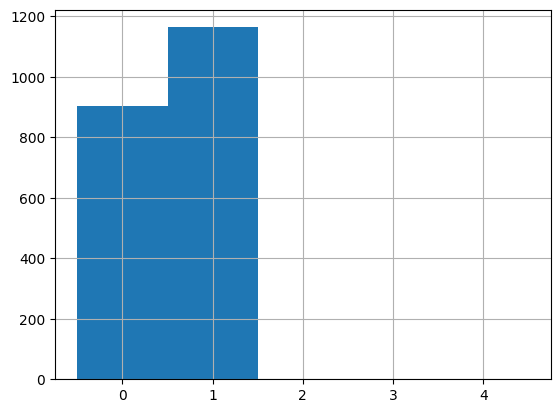

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

outcomes = np.unique(test_df['Outcome'])
le.fit(list(set(outcomes)))
y = le.transform(test_df['Outcome'])

print("Classes                          : ", outcomes)
print("Number of cpds in each class     : ", np.unique([len(y[y == smi]) for smi in y]))
print("Total number of cpds             : ", len(y))

S = test_df['Outcome']
info = {}
for i, cls in enumerate(S.unique()):
    info.update({cls: i})
    S = S.replace(cls, i)

ax = S.hist(bins=np.arange(-0.5, 5))
ax.set_xticks(range(0, 5))
info


In [9]:
test_df = test_df.rename(columns={'labels': 'Outcome'})

In [10]:
x_data = test_df

In [11]:
test_df

,smiles,Outcome,IUPAC name,ID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,Molecular weight,Molecule (RDKit Mol) (InChI Code),nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Molecular Weight,AMW,logP,ALogP,ALogP2,MLogP,TPSA,AMR,LabuteASA,NumLipinskiHBA,NumHBA,nHBAcc,NumLipinskiHBD,NumHBD,NumRotatableBonds,NumAmideBonds,NumHeteroAtoms,NumAtoms,NumRings,NumAromaticRings,naAromAtom,NumSaturatedRings,NumAliphaticRings,NumAromaticHeterocycles,NumSaturatedHeterocycles,NumAliphaticHeterocycles,NumAromaticCarbocycles,NumSaturatedCarbocycles,NumAliphaticCarbocycles,Chi0v,Chi1v,Chi2v,Chi3v,Chi4v,Chi1n,Chi2n,Chi3n,Chi4n,HallKierAlpha,kappa1,kappa2,kappa3,FractionCSP3,bpol,nB,ECCEN,fragC,nAtomP,Outcome,RowID
0,Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...,0,"N-[(2R)-3-[4-(2,4-dichloro-3-methylphenoxy)pip...",,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.690806048294513, 0.2924079450017158, 0.5112...",Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...,582.506,InChI=1S/C26H29Cl2N3O6S/c1-15-22(27)5-6-23(24(...,3,7,38.0,0.5,8,0.0,128.80,1.301182,3.18092,0.384615,582.506,582.506,3.18092,3.18092,10.118252,3.18092,128.80,147.3075,230.170792,7,7,7,3,3,8,1,12,38,4,3,3,1,1,1,1,1,2,0,0,23.289643,14.738582,12.278101,8.615918,5.505417,12.091241,9.477201,6.626484,4.443066,-2.63,28.379878,11.628461,6.495380,0.384615,553.274,8,0.0,0.0,38.0,0,0
800,CCOc1c([C@H](C)n2nc(C)c3c(N)ncnc32)cc(Cl)c(F)c...,0,"(4R)-4-[3-[(1S)-1-(4-amino-3-methylpyrazolo[3,...",,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.17780262273425018, 0.39623264933813196, 0.3...",CCOc1c([C@H](C)n2nc(C)c3c(N)ncnc32)cc(Cl)c(F)c...,432.887,InChI=1S/C20H22ClFN6O2/c1-4-30-18-12(6-13(21)1...,2,7,30.0,0.5,5,0.0,107.95,1.913936,3.12092,0.400000,432.887,432.887,3.12092,3.12092,9.740142,3.12092,107.95,111.2321,177.128961,7,7,7,2,2,5,1,10,30,4,3,3,1,1,2,1,1,1,0,0,17.625281,10.073312,7.713205,5.694645,4.229248,9.695348,7.306005,5.419617,4.009899,-2.94,20.337551,7.714161,3.225858,0.400000,410.711,5,0.0,0.0,30.0,0,800
801,Cc1cc(Cl)ccc1OC1CCN(C[C@H](O)CNC(=O)c2c[nH]c(=...,0,N-[(2R)-3-[4-(4-chloro-2-methylphenoxy)piperid...,,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.4341065701228783, 0.35130849842333645, 0.15...",Cc1cc(Cl)ccc1OC1CCN(C[C@H](O)CNC(=O)c2c[nH]c(=...,487.959,InChI=1S/C25H27ClFN3O4/c1-15-11-16(26)5-6-22(1...,3,5,34.0,0.5,7,0.0,94.66,1.264930,3.26312,0.360000,487.959,487.959,3.26312,3.26312,10.647952,3.26312,94.66,129.1457,201.042720,5,5,5,3,3,7,1,9,34,4,3,3,1,1,1,1,1,2,0,0,19.569823,11.606833,9.021792,6.290577,4.484141,11.228869,8.585356,6.055480,4.257484,-2.94,24.193022,10.546907,5.575670,0.360000,460.743,7,0.0,0.0,34.0,0,801
802,Cc1c([C@H]2CN3CCN(C(=O)Cc4ccc(-n5cnnn5)cn4)C[C...,0,"3-[(3S,9aS)-8-[2-[5-(tetrazol-1-yl)pyridin-2-y...",,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8858027243170344, 0.9972179571316186, 0.539...",Cc1c([C@H]2CN3CCN(C(=O)Cc4ccc(-n5cnnn5)cn4)C[C...,462.489,InChI=1S/C23H23FN8O2/c1-15-19(4-5-21(24)20(15)...,0,9,34.0,0.5,4,0.0,113.06,1.190500,1.20330,0.391304,462.489,462.489,1.20330,1.20330,1.447931,1.20330,113.06,117.1390,195.104227,9,9,9,0,0,4,1,11,34,5,3,3,2,2,2,2,2,1,0,0,18.633613,11.040187,8.497812,6.517267,4.582841,11.040187,8.497812,6.517267,4.582841,-3.75,22.062563,9.244654,4.250684,0.391304,439.305,4,0.0,0.0,34.0,0,802
1634,CC1(C)Cc2c(CN3CCC4(CC3)CCN(C(=O)c3ccc(N)cn3)CC...,0,"(5-aminopyridin-2-yl)-[9-[(2,2-dimethyl-3H-1-b...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4437740027614739, -0.16182513647010524, -0...",CC1(C)Cc2c(CN3CCC4(CC3)CCN(C(=O)c3ccc(N)cn3)CC...,434.584,InChI=1S/C26H34N4O2/c1-25(2)16-21-19(4-3-5-23(...,1,5,32.0,0.5,3,0.0,71.69,1.155670,3.89570,0.538462,434.584,434.584,3.8

In [12]:
x_data = test_df.drop(columns=['smiles', 'Outcome', 'IUPAC name', 'ID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular Weight',
       'Molecule (RDKit Mol) (InChI Code)','RowID','ALogP','ALogP2'])
print(x_data)

      Molecular weight  nHBDon  nAtomLAC  nAtomLC  PetitjeanNumber  nRotB  \
0              582.506       3         7     38.0              0.5      8   
800            432.887       2         7     30.0              0.5      5   
801            487.959       3         5     34.0              0.5      7   
802            462.489       0         9     34.0              0.5      4   
1634           434.584       1         5     32.0              0.5      3   
...                ...     ...       ...      ...              ...    ...   
892            419.445       2         9     31.0              0.5      4   
888            452.961       1         3     32.0              0.5      6   
887            507.566       2         8     37.0              0.5      7   
881            546.756       2         4     40.0              0.5      7   
2067           393.840       0         3     27.0              0.5      4   

      LipinskiFailures  TopoPSA   VAdjMat    XLogP      Fsp3      AMW  \
0 

In [13]:
x_data  = x_data.apply(lambda row: row.values, axis=1).tolist()

# Add the new column 'rdkit_cdk' to test_df
test_df['rdkit_cdk'] = x_data

# Display the updated DataFrame
print(test_df)

                                                 smiles Outcome  \
0     Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...       0   
800   CCOc1c([C@H](C)n2nc(C)c3c(N)ncnc32)cc(Cl)c(F)c...       0   
801   Cc1cc(Cl)ccc1OC1CCN(C[C@H](O)CNC(=O)c2c[nH]c(=...       0   
802   Cc1c([C@H]2CN3CCN(C(=O)Cc4ccc(-n5cnnn5)cn4)C[C...       0   
1634  CC1(C)Cc2c(CN3CCC4(CC3)CCN(C(=O)c3ccc(N)cn3)CC...       0   
...                                                 ...     ...   
892   CC(C)(C)c1cc(NC(=O)c2cnc3cc(Oc4ncnc5c4CNC5)ccn...       1   
888   O=C(NCc1ccc(F)cc1)N(c1ccc(Cl)cc1)C1CCN(Cc2ccnc...       1   
887   COc1cc(C)c2ncc(F)c(CCC34CCC(NCc5ccc6c(n5)NC(=O...       1   
881   COc1ccc([C@@H](C)N[C@@H]2CC[C@@H](C(=O)N3CCC(c...       1   
2067  CN1CC[C@@H](N(Cc2ccccc2C(F)(F)F)c2ccc(C#N)c(Cl...       1   

                                             IUPAC name ID  \
0     N-[(2R)-3-[4-(2,4-dichloro-3-methylphenoxy)pip...      
800   (4R)-4-[3-[(1S)-1-(4-amino-3-methylpyrazolo[3,...      
801   N-[

In [14]:
test_df = test_df.drop(
    ['Molecule (RDKit Mol) (InChI Code)', 'ECCEN', 'nB', 'fragC'],
    axis=1
)

print(test_df)

                                                 smiles Outcome  \
0     Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...       0   
800   CCOc1c([C@H](C)n2nc(C)c3c(N)ncnc32)cc(Cl)c(F)c...       0   
801   Cc1cc(Cl)ccc1OC1CCN(C[C@H](O)CNC(=O)c2c[nH]c(=...       0   
802   Cc1c([C@H]2CN3CCN(C(=O)Cc4ccc(-n5cnnn5)cn4)C[C...       0   
1634  CC1(C)Cc2c(CN3CCC4(CC3)CCN(C(=O)c3ccc(N)cn3)CC...       0   
...                                                 ...     ...   
892   CC(C)(C)c1cc(NC(=O)c2cnc3cc(Oc4ncnc5c4CNC5)ccn...       1   
888   O=C(NCc1ccc(F)cc1)N(c1ccc(Cl)cc1)C1CCN(Cc2ccnc...       1   
887   COc1cc(C)c2ncc(F)c(CCC34CCC(NCc5ccc6c(n5)NC(=O...       1   
881   COc1ccc([C@@H](C)N[C@@H]2CC[C@@H](C(=O)N3CCC(c...       1   
2067  CN1CC[C@@H](N(Cc2ccccc2C(F)(F)F)c2ccc(C#N)c(Cl...       1   

                                             IUPAC name ID  \
0     N-[(2R)-3-[4-(2,4-dichloro-3-methylphenoxy)pip...      
800   (4R)-4-[3-[(1S)-1-(4-amino-3-methylpyrazolo[3,...      
801   N-[

In [15]:
test_df = test_df.loc[:,~test_df.columns.duplicated()]
y_true = test_df['Outcome'].astype(int).values


In [16]:
y_test= np.int32((S))
x_test_morgan = np.array(list(test_df['Morgan_Descriptors']))
x_test_macckeys = np.array(list(test_df['MACCS_Descriptors']))
x_test_modred= np.array(list(test_df['Modred_Descriptor']))
x_test_rdkit_cdk = np.array(list(test_df['rdkit_cdk']))

In [17]:
x_test_rdkit_cdk

array([[582.506,   3.   ,   7.   , ...,   0.   ,   0.   ,  38.   ],
       [432.887,   2.   ,   7.   , ...,   0.   ,   0.   ,  30.   ],
       [487.959,   3.   ,   5.   , ...,   0.   ,   0.   ,  34.   ],
       ...,
       [507.566,   2.   ,   8.   , ...,   0.   ,   0.   ,  37.   ],
       [546.756,   2.   ,   4.   , ...,   0.   ,   0.   ,  40.   ],
       [393.84 ,   0.   ,   3.   , ...,   0.   ,   0.   ,  27.   ]])

In [18]:
import joblib
import numpy as np
import ast

# Function to ensure data is a NumPy array
def ensure_numpy_array(data):
    if isinstance(data, np.ndarray):
        return data
    elif isinstance(data, list):
        return np.array(data)
    elif hasattr(data, 'to_numpy'):  # For Pandas DataFrame
        return data.to_numpy()
    else:
        raise ValueError("Data format not recognized. Ensure it is a list, numpy array, or pandas DataFrame.")

# Function to check if all elements are numerical
def check_numerical(data):
    if not np.issubdtype(data.dtype, np.number):
        raise ValueError("Data contains non-numerical values. Ensure all elements are numerical.")

# Function to convert string representations of lists to numerical arrays
def parse_string_lists(data):
    parsed_data = []
    for item in data:
        if isinstance(item, str):
            try:
                parsed_item = ast.literal_eval(item)
                parsed_data.append(parsed_item)
            except (ValueError, SyntaxError):
                raise ValueError(f"Cannot parse value '{item}'")
        else:
            parsed_data.append(item)
    return np.array(parsed_data)

# Ensure training data is properly formatted
x_test_morgan = ensure_numpy_array(x_test_morgan)
x_test_macckeys = ensure_numpy_array(x_test_macckeys)
x_test_modred = ensure_numpy_array(x_test_modred)

check_numerical(x_test_morgan)
check_numerical(x_test_macckeys)

# Parse and convert string lists in x_test_modred
x_test_modred = parse_string_lists(x_test_modred)
check_numerical(x_test_modred)





In [19]:
x_test = np.concatenate((x_test_morgan, x_test_macckeys, x_test_modred), axis=1)

In [21]:
#load model - all included
import joblib

# Base paths
fingerprint_path = r"D:\Riset QSAR - TTX\Machine Learning (Done)\Cardiac\Model\Descriptor"
phys_path        = r"D:\Riset QSAR - TTX\Machine Learning (Done)\Cardiac\Model\Physiochemical"

# descriptor
rf_morgan   = joblib.load(fr"{fingerprint_path}\Model_Cardiac_RF_morgan.pkl")  
rf_maccs    = joblib.load(fr"{fingerprint_path}\Model_Cardiac_RF_maccs.pkl")
rf_modred   = joblib.load(fr"{fingerprint_path}\Model_Cardiac_RF_modred.pkl")

svm_morgan  = joblib.load(fr"{fingerprint_path}\Model_Cardiac_SVM_morgan.pkl")  
svm_maccs   = joblib.load(fr"{fingerprint_path}\Model_Cardiac_SVM_maccs.pkl")
svm_modred  = joblib.load(fr"{fingerprint_path}\Model_Cardiac_SVM_modred.pkl")

xgb_morgan  = joblib.load(fr"{fingerprint_path}\Model_Cardiac_XGB_morgan.pkl")  
xgb_maccs   = joblib.load(fr"{fingerprint_path}\Model_Cardiac_XGB_maccs.pkl")
xgb_modred  = joblib.load(fr"{fingerprint_path}\Model_Cardiac_XGB_modred.pkl")

nn_morgan   = joblib.load(fr"{fingerprint_path}\Model_Cardiac_NN_morgan.pkl")  
nn_maccs    = joblib.load(fr"{fingerprint_path}\Model_Cardiac_NN_maccs.pkl")
nn_modred   = joblib.load(fr"{fingerprint_path}\Model_Cardiac_NN_modred.pkl")

lgbm_morgan = joblib.load(fr"{fingerprint_path}\Model_Cardiac_LGBM_morgan.pkl")  
lgbm_maccs  = joblib.load(fr"{fingerprint_path}\Model_Cardiac_LGBM_maccs.pkl")
lgbm_modred = joblib.load(fr"{fingerprint_path}\Model_Cardiac_LGBM_modred.pkl")

# physiochemical
rf_phys   = joblib.load(fr"{phys_path}\Model_Cardiac_RF_phys.pkl")
svm_phys  = joblib.load(fr"{phys_path}\Model_Cardiac_SVM_phys.pkl")
xgb_phys  = joblib.load(fr"{phys_path}\Model_Cardiac_XGB_phys.pkl")
nn_phys   = joblib.load(fr"{phys_path}\Model_Cardiac_NN_phys.pkl")
lgbm_phys = joblib.load(fr"{phys_path}\Model_Cardiac_LGBM_phys.pkl")


In [22]:
#physiochemical consensus here - only phys
#descriptor not yet included here!
# Predict with all phys models (RF, SVM, XGB, NN, LGBM)


#PHYSICOCHEMICAL CONSENSUS
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_phys_models(test_df):
    # Get probabilities from each phys model
    rf_probs   = rf_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    svm_probs  = svm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs  = xgb_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    nn_probs   = nn_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs = lgbm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate mean probability across all phys models
    consensus_physicochemical_probs = np.mean(
        [rf_probs, svm_probs, xgb_probs, nn_probs, lgbm_probs],
        axis=0
    )

    # Convert mean probabilities to final class predictions (threshold = 0.5)
    final_predictions = (consensus_physicochemical_probs > 0.5).astype(int)

    return final_predictions, consensus_physicochemical_probs

# ==============================
# Run prediction
# ==============================
final_predictions, consensus_physicochemical_probs = predict_with_phys_models(test_df)
test_df['Phys_Predictions'] = final_predictions
test_df['Phys_Consensus_Probabilities'] = consensus_physicochemical_probs

y_true = test_df['Outcome'].astype(int)

# ==============================
# Evaluate performance
# ==============================
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, consensus_physicochemical_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)


Confusion Matrix:
[[607 297]
 [184 980]]
Accuracy: 0.7674081237911026
AUC Score: 0.8415803758781133
F1 Score: 0.8029496108152396
Sensitivity: 0.8419243986254296
Specificity: 0.6714601769911505
CCR (Correct Classification Rate): 0.75669228780829
PPV (Positive Predictive Value): 0.7674236491777604
NPV (Negative Predictive Value): 0.7673830594184576


In [ ]:
#indicidual on decriptor

In [23]:
# RF
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_rf_from_pkl(test_df, rf_morgan, rf_maccs, rf_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :rf_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :rf_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :rf_modred.n_features_in_]

    return {
        "Morgan": rf_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  rf_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": rf_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }


# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_rf = predict_probabilities_rf_from_pkl(
    test_df,
    rf_morgan,
    rf_maccs,
    rf_modred
)

# Results
for model_name, y_prob in probs_rf.items():
    print(f"\n{model_name} RF Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_rf = consensus_probability(probs_rf)
consensus_metrics_rf = evaluate_model(y_true, consensus_probs_rf)

print("\nCONSENSUS RF (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_rf.items():
    print(f"{k}: {v}")



Morgan RF Performance
Confusion Matrix: [[607 297]
 [168 996]]
Accuracy: 0.7751450676982592
AUC: 0.8690461256576346
F1 Score: 0.8107448107448108
Sensitivity: 0.8556701030927835
Specificity: 0.6714601769911505
CCR: 0.763565140041967
PPV (Precision): 0.7703016241299304
NPV: 0.7832258064516129

MACCS RF Performance
Confusion Matrix: [[636 268]
 [184 980]]
Accuracy: 0.781431334622824
AUC: 0.8525026229358634
F1 Score: 0.8126036484245439
Sensitivity: 0.8419243986254296
Specificity: 0.7035398230088495
CCR: 0.7727321108171396
PPV (Precision): 0.7852564102564102
NPV: 0.775609756097561

Modred RF Performance
Confusion Matrix: [[ 631  273]
 [ 155 1009]]
Accuracy: 0.793036750483559
AUC: 0.8727752562114162
F1 Score: 0.8250204415372036
Sensitivity: 0.8668384879725086
Specificity: 0.6980088495575221
CCR: 0.7824236687650153
PPV (Precision): 0.7870514820592823
NPV: 0.8027989821882952

CONSENSUS RF (Morgan + MACCS + Modred)
Confusion Matrix: [[ 640  264]
 [ 161 1003]]
Accuracy: 0.7944874274661509
AUC: 

In [24]:
# SVM
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, svm_morgan, svm_maccs, svm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :svm_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :svm_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :svm_modred.n_features_in_]

    return {
        "Morgan": svm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  svm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": svm_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_svm = predict_probabilities_from_pkl(
    test_df,
    svm_morgan,
    svm_maccs,
    svm_modred
)

for model_name, y_prob in probs_svm.items():
    print(f"\n{model_name} SVM Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_svm = consensus_probability(probs_svm)
consensus_metrics_svm = evaluate_model(y_true, consensus_probs_svm)

print("\nCONSENSUS SVM (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_svm.items():
    print(f"{k}: {v}")



Morgan SVM Performance
Confusion Matrix: [[643 261]
 [169 995]]
Accuracy: 0.7920696324951644
AUC: 0.8717911800930571
F1 Score: 0.8223140495867769
Sensitivity (Recall+): 0.8548109965635738
Specificity (Recall-): 0.7112831858407079
CCR: 0.7830470912021409
PPV (Precision): 0.7921974522292994
NPV: 0.791871921182266

MACCS SVM Performance
Confusion Matrix: [[648 256]
 [195 969]]
Accuracy: 0.7819148936170213
AUC: 0.8500459964115195
F1 Score: 0.8112180828798661
Sensitivity (Recall+): 0.8324742268041238
Specificity (Recall-): 0.7168141592920354
CCR: 0.7746441930480796
PPV (Precision): 0.7910204081632654
NPV: 0.7686832740213523

Modred SVM Performance
Confusion Matrix: [[638 266]
 [182 982]]
Accuracy: 0.7833655705996132
AUC: 0.8659684525438676
F1 Score: 0.814262023217247
Sensitivity (Recall+): 0.8436426116838488
Specificity (Recall-): 0.7057522123893806
CCR: 0.7746974120366147
PPV (Precision): 0.7868589743589743
NPV: 0.7780487804878049

CONSENSUS SVM (Morgan + MACCS + Modred)
Confusion Matrix:

In [25]:
# XGB
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_from_pkl(test_df, xgb_morgan, xgb_maccs, xgb_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :xgb_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :xgb_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :xgb_modred.n_features_in_]

    return {
        "Morgan": xgb_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  xgb_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": xgb_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_xgb = predict_probabilities_from_pkl(
    test_df,
    xgb_morgan,
    xgb_maccs,
    xgb_modred
)

# Results
for model_name, y_prob in probs_xgb.items():
    print(f"\n{model_name} XGB Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")
consensus_probs_xgb = consensus_probability(probs_xgb)
consensus_metrics_xgb = evaluate_model(y_true, consensus_probs_xgb)

print("\nCONSENSUS XGB (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_xgb.items():
    print(f"{k}: {v}")




Morgan XGB Performance
Confusion Matrix: [[648 256]
 [171 993]]
Accuracy: 0.7935203094777563
AUC: 0.870875528388529
F1 Score: 0.823041856610029
Sensitivity (Recall+): 0.8530927835051546
Specificity (Recall-): 0.7168141592920354
CCR: 0.7849534713985951
PPV (Precision): 0.7950360288230585
NPV: 0.7912087912087912

MACCS XGB Performance
Confusion Matrix: [[657 247]
 [214 950]]
Accuracy: 0.7770793036750484
AUC: 0.8516682252227594
F1 Score: 0.8047437526471835
Sensitivity (Recall+): 0.8161512027491409
Specificity (Recall-): 0.7267699115044248
CCR: 0.7714605571267829
PPV (Precision): 0.7936507936507936
NPV: 0.7543053960964409

Modred XGB Performance
Confusion Matrix: [[670 234]
 [196 968]]
Accuracy: 0.7920696324951644
AUC: 0.8767153620411763
F1 Score: 0.8182586644125106
Sensitivity (Recall+): 0.8316151202749141
Specificity (Recall-): 0.7411504424778761
CCR: 0.7863827813763951
PPV (Precision): 0.8053244592346089
NPV: 0.7736720554272517

CONSENSUS XGB (Morgan + MACCS + Modred)
Confusion Matrix:

In [26]:
# NN 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_from_pkl(test_df, nn_morgan, nn_maccs, nn_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :nn_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :nn_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :nn_modred.n_features_in_]

    return {
        "Morgan": nn_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  nn_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": nn_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs = predict_probabilities_from_pkl(
    test_df,
    nn_morgan,
    nn_maccs,
    nn_modred
)

# Results
for model_name, y_prob in probs.items():
    print(f"\n{model_name} Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_nn = consensus_probability(probs)
consensus_metrics_nn = evaluate_model(y_true, consensus_probs_nn)

print("\n CONSENSUS NN (Morgan + MACCS + Modred) ")
for k, v in consensus_metrics_nn.items():
    print(f"{k}: {v}")



Morgan Performance
Confusion Matrix: [[647 257]
 [203 961]]
Accuracy: 0.7775628626692457
AUC: 0.8504204300094274
F1 Score: 0.8068849706129303
Sensitivity (Recall+): 0.8256013745704467
Specificity (Recall-): 0.7157079646017699
CCR: 0.7706546695861083
PPV (Precision): 0.7889983579638752
NPV: 0.7611764705882353

MACCS Performance
Confusion Matrix: [[653 251]
 [242 922]]
Accuracy: 0.761605415860735
AUC: 0.8391855213940334
F1 Score: 0.789045785194694
Sensitivity (Recall+): 0.7920962199312714
Specificity (Recall-): 0.7223451327433629
CCR: 0.7572206763373172
PPV (Precision): 0.7860187553282183
NPV: 0.729608938547486

Modred Performance
Confusion Matrix: [[656 248]
 [194 970]]
Accuracy: 0.7862669245647969
AUC: 0.8506456603716206
F1 Score: 0.8144416456759026
Sensitivity (Recall+): 0.8333333333333334
Specificity (Recall-): 0.7256637168141593
CCR: 0.7794985250737463
PPV (Precision): 0.7963875205254516
NPV: 0.7717647058823529

 CONSENSUS NN (Morgan + MACCS + Modred) 
Confusion Matrix: [[674 230]


In [27]:
# LGBM - Consensus
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Prediction Function (PKL-based)
# ==============================
def predict_probabilities_from_pkl(test_df, lgbm_morgan, lgbm_maccs, lgbm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :lgbm_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :lgbm_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :lgbm_modred.n_features_in_]

    return {
        "Morgan": lgbm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  lgbm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": lgbm_modred.predict_proba(X_modred)[:, 1]
    }

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# Consensus Function (Neutral)
# ==============================
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

# ==============================
# RUN PREDICTION
# ==============================
probs = predict_probabilities_from_pkl(
    test_df,
    lgbm_morgan,
    lgbm_maccs,
    lgbm_modred
)

# ==============================
# PRINT INDIVIDUAL MODEL RESULTS
# ==============================
for model_name, y_prob in probs.items():
    print(f"\n===== {model_name} Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

# ==============================
# CONSENSUS RESULT
# ==============================
consensus_probs_lgbm = consensus_probability(probs)
consensus_metrics_lgbm = evaluate_model(y_true, consensus_probs_lgbm)

print("\n===== CONSENSUS LGBM (Morgan + MACCS + Modred) =====")
for k, v in consensus_metrics_lgbm.items():
    print(f"{k}: {v}")



===== Morgan Performance =====
Confusion Matrix: [[679 225]
 [213 951]]
Accuracy: 0.7882011605415861
AUC: 0.8693131709393911
F1 Score: 0.8128205128205128
Sensitivity (Recall+): 0.8170103092783505
Specificity (Recall-): 0.7511061946902655
CCR: 0.784058251984308
PPV (Precision): 0.8086734693877551
NPV: 0.7612107623318386

===== MACCS Performance =====
Confusion Matrix: [[701 203]
 [237 927]]
Accuracy: 0.7872340425531915
AUC: 0.8623890003953409
F1 Score: 0.8081952920662598
Sensitivity (Recall+): 0.7963917525773195
Specificity (Recall-): 0.7754424778761062
CCR: 0.7859171152267128
PPV (Precision): 0.820353982300885
NPV: 0.7473347547974414

===== Modred Performance =====
Confusion Matrix: [[700 204]
 [186 978]]
Accuracy: 0.811411992263056
AUC: 0.891907482589788
F1 Score: 0.8337595907928389
Sensitivity (Recall+): 0.8402061855670103
Specificity (Recall-): 0.7743362831858407
CCR: 0.8072712343764255
PPV (Precision): 0.8274111675126904
NPV: 0.7900677200902935

===== CONSENSUS LGBM (Morgan + MACC

In [28]:
# ==============================
# CONSENSUS ALL (RF + SVM + XGB + NN + LGBM)
# ==============================
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# STACK ALL MODEL CONSENSUS
# ==============================
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

# ==============================
# FINAL CONSENSUS (MEAN)
# ==============================
consensus_all_probs = all_model_probs.mean(axis=0)

# ==============================
# EVALUATION
# ==============================
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)
Confusion Matrix: [[680 224]
 [166 998]]
Accuracy: 0.811411992263056
AUC: 0.898301363926649
F1 Score: 0.8365465213746857
Sensitivity (Recall+): 0.8573883161512027
Specificity (Recall-): 0.7522123893805309
CCR: 0.8048003527658668
PPV (Precision): 0.8166939443535188
NPV: 0.8037825059101655


In [29]:
# PHYSICOCHEMICAL + DESCRIPTOR

import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Evaluation Function 
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# STACK CONSENSUS PROBABILITIES
all_consensus_stack = np.vstack([
    consensus_physicochemical_probs,
    consensus_all_probs
])

# FINAL CONSENSUS (MEAN)
all_consensus_probs = all_consensus_stack.mean(axis=0)

# EVALUATION
all_consensus_metrics = evaluate_model(
    y_true,
    all_consensus_probs  
)

print("CONSENSUS: PHYSICOCHEMICAL + DESCRIPTOR")
for k, v in all_consensus_metrics.items():
    print(f"{k}: {v}")



CONSENSUS: PHYSICOCHEMICAL + DESCRIPTOR
Confusion Matrix: [[ 666  238]
 [ 154 1010]]
Accuracy: 0.8104448742746615
AUC: 0.8886734786971993
F1 Score: 0.8374792703150912
Sensitivity (Recall+): 0.8676975945017182
Specificity (Recall-): 0.7367256637168141
CCR: 0.8022116291092662
PPV (Precision): 0.8092948717948718
NPV: 0.8121951219512196


In [ ]:
#read accross

In [30]:
from rdkit import Chem, DataStructs
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Buat fingerprint dari test set (Morgan misalnya)
test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

# Probabilitas prediksi untuk semua test (leave-one-out)
consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5) 
    for i in range(len(test_fps))
])

# Konversi ke prediksi biner
final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)

# Fungsi evaluasi sesuai format yang diinginkan
def evaluate_performance(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # Recall+
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # Recall-
    ccr = (sensitivity + specificity) / 2
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0           # Precision
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    
    return {
        "Accuracy": accuracy,
        "AUC": auc,
        "F1 Score": f1,
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": ccr,
        "PPV (Precision)": ppv,
        "NPV": npv
    }

# Evaluasi
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6794003868471954
AUC: 0.7538369940394734
F1 Score: 0.711864406779661
Sensitivity (Recall+): 0.7036082474226805
Specificity (Recall-): 0.6482300884955752
CCR: 0.6759191679591279
PPV (Precision): 0.7203166226912929
NPV: 0.6294307196562836


In [31]:
# READ-ACROSS (Leave-One-Out, Tanimoto)
from rdkit import Chem, DataStructs

test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5)
    for i in range(len(test_fps))
])

final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")



# CONSENSUS ALL ALGORITHM (RF + SVM + XGB + NN + LGBM)
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

consensus_all_probs = all_model_probs.mean(axis=0)
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("\n=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")

# Gabungan probabilitas (mean dari RA dan Consensus All Algorithm)
consensus_ra_all_probs = np.mean([
    consensus_probs_ra,
    consensus_all_probs
], axis=0)

# Konversi ke prediksi biner
final_predictions_ra_all = (consensus_ra_all_probs >= 0.5).astype(int)

# Evaluasi gabungan
ensemble_performance_ra_all = evaluate_performance(y_true, final_predictions_ra_all, consensus_ra_all_probs)

print("\n=== Combined Consensus (Read-Across + Consensus All Algorithm) Performance ===")
for metric, value in ensemble_performance_ra_all.items():
    print(f"{metric}: {value}")




=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6794003868471954
AUC: 0.7538369940394734
F1 Score: 0.711864406779661
Sensitivity (Recall+): 0.7036082474226805
Specificity (Recall-): 0.6482300884955752
CCR: 0.6759191679591279
PPV (Precision): 0.7203166226912929
NPV: 0.6294307196562836

=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===
Confusion Matrix: [[680 224]
 [166 998]]
Accuracy: 0.811411992263056
AUC: 0.898301363926649
F1 Score: 0.8365465213746857
Sensitivity (Recall+): 0.8573883161512027
Specificity (Recall-): 0.7522123893805309
CCR: 0.8048003527658668
PPV (Precision): 0.8166939443535188
NPV: 0.8037825059101655

=== Combined Consensus (Read-Across + Consensus All Algorithm) Performance ===
Accuracy: 0.7756286266924565
AUC: 0.8703195800261533
F1 Score: 0.8048780487804879
Sensitivity (Recall+): 0.8221649484536082
Specificity (Recall-): 0.7157079646017699
CCR: 0.768936456527689
PPV (Precision): 0.788303130148270

In [32]:
# READ-ACROSS (Leave-One-Out, Tanimoto)
from rdkit import Chem, DataStructs
import numpy as np

test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5)
    for i in range(len(test_fps))
])

final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")


# CONSENSUS ALL ALGORITHM (RF + SVM + XGB + NN + LGBM)
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

consensus_all_probs = all_model_probs.mean(axis=0)
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("\n=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


# PHYSICOCHEMICAL CONSENSUS
rf_probs   = rf_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
svm_probs  = svm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
xgb_probs  = xgb_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
nn_probs   = nn_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
lgbm_probs = lgbm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

consensus_physicochemical_probs = np.mean(
    [rf_probs, svm_probs, xgb_probs, nn_probs, lgbm_probs],
    axis=0
)

final_predictions_phys = (consensus_physicochemical_probs >= 0.5).astype(int)
ensemble_performance_phys = evaluate_performance(y_true, final_predictions_phys, consensus_physicochemical_probs)

print("\n=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===")
for metric, value in ensemble_performance_phys.items():
    print(f"{metric}: {value}")


# COMBINED CONSENSUS (RA + All Algorithm + Physicochemical)
consensus_ra_all_phys_probs = np.mean([
    consensus_probs_ra,
    consensus_all_probs,
    consensus_physicochemical_probs
], axis=0)

final_predictions_ra_all_phys = (consensus_ra_all_phys_probs >= 0.5).astype(int)
ensemble_performance_ra_all_phys = evaluate_performance(y_true, final_predictions_ra_all_phys, consensus_ra_all_phys_probs)

print("\n=== Combined Consensus (Read-Across + Consensus All Algorithm + Physicochemical) Performance ===")
for metric, value in ensemble_performance_ra_all_phys.items():
    print(f"{metric}: {value}")



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6794003868471954
AUC: 0.7538369940394734
F1 Score: 0.711864406779661
Sensitivity (Recall+): 0.7036082474226805
Specificity (Recall-): 0.6482300884955752
CCR: 0.6759191679591279
PPV (Precision): 0.7203166226912929
NPV: 0.6294307196562836

=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===
Confusion Matrix: [[680 224]
 [166 998]]
Accuracy: 0.811411992263056
AUC: 0.898301363926649
F1 Score: 0.8365465213746857
Sensitivity (Recall+): 0.8573883161512027
Specificity (Recall-): 0.7522123893805309
CCR: 0.8048003527658668
PPV (Precision): 0.8166939443535188
NPV: 0.8037825059101655

=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===
Accuracy: 0.7674081237911026
AUC: 0.8415803758781133
F1 Score: 0.8029496108152396
Sensitivity (Recall+): 0.8419243986254296
Specificity (Recall-): 0.6714601769911505
CCR: 0.75669228780829
PPV (Precision): 0.7674236491777604
NPV